In [1]:
#2026-02-25 - Try to search for specific data for dt_select:

import datetime
import xarray as xr
from itertools import islice
from io import BytesIO

from edlcli.edl import Edl
from edlcli.cli_helpers import load_credentials
from edlcli.token import EDLApiKey

dt_select = datetime.datetime(2025, 7, 16, 6, 0, 0)

creds = load_credentials()
token = EDLApiKey(creds)  # type: ignore[arg-type]
edl = Edl(token)

collection = edl.get_collection("EO:EUM:DAT:0905")
query_result = collection.search(dtstart = dt_select, dtend = dt_select, set="brief")
for product in islice(query_result, 1):
    print(product)
    with product.open(entry=f"{product}.nc") as fsrc:
        nc_bytes = BytesIO()
        while True:
            chunk = fsrc.read(1024 * 1024)  # type: ignore
            if not chunk:
                break
            nc_bytes.write(chunk)
    nc_bytes.seek(0)
    dataset = xr.open_dataset(nc_bytes, engine="h5netcdf")
#    print(dataset)
    dsdn = xr.open_dataset(nc_bytes, engine="h5netcdf", group='data/navigation')
    dsdm = xr.open_dataset(nc_bytes, engine="h5netcdf", group='data/measurement')
    dsdc = xr.open_dataset(nc_bytes, engine="h5netcdf", group='data/calibration')
    dsdp = xr.open_dataset(nc_bytes, engine="h5netcdf", group='data/processing_information') #flags, etc



W_NO-KSAT-Tromso,SAT,AWS1-MWR-1B-RAD_C_OHB__20250716065352_G_O_20250716050502_20250716064223_C_N____


1 4289 13
2 4265 13
3 4290 13
4 4284 13
5 4273 13
6 3312 22
7 4151 14
8 3368 22
9 2636 24
10 406 13
11 412 13
12 412 13
13 408 13
14 412 13
15 421 13
16 4797 14
17 4789 14
18 4801 14
19 4792 14


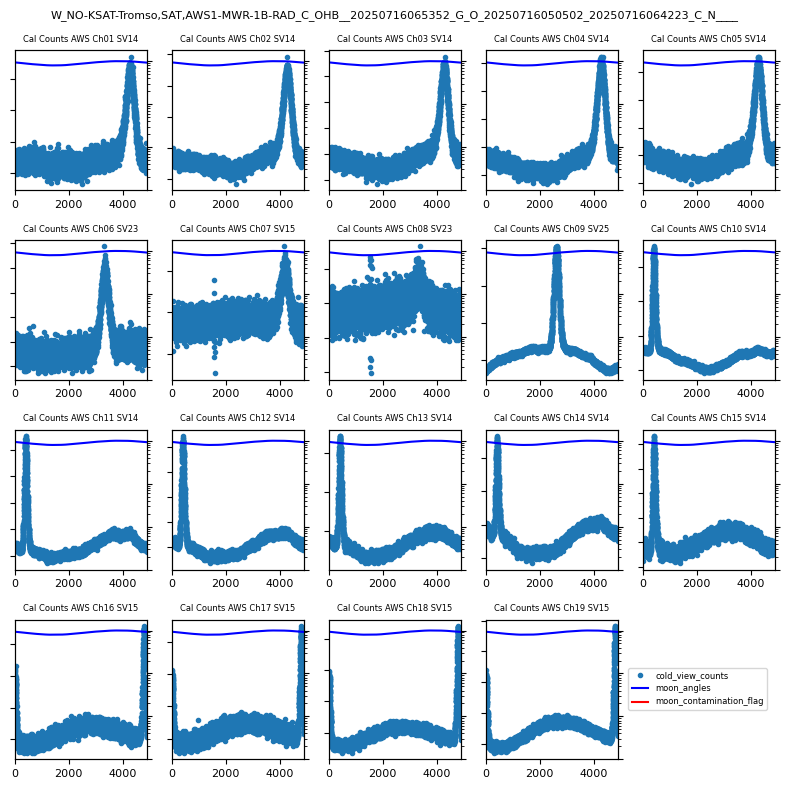

In [2]:
#Check Moon flagging on lunar intrusion - for ESA IPF L1B

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import ntpath

ihorn=[0,0,0,0,0,0,0,0,1,2,2,2,2,2,2,3,3,3,3]
xrange=[300,300,300,300,300,300,300,300,200,100,100,100,100,100,100,100,100,100,100]

#Plot time series of space counts every space views for all channels + Overplot Moon Angle

fig, ax = plt.subplots(4, 5, sharex=False, sharey=False, figsize=(8,8)) 
ax = ax.ravel()

fig.suptitle(dataset.product_name[:-3], fontsize=8)
blanx = ["_" for x in range(19)]
blanx[18]=""

for ich in range(19): #now ich = plot counter, ch=channel number-1
    #Find the Moon! Highest count in any Space View for each channel
    Cs=dsdm.aws_cold_view_counts[:,:,ich]
    # Convert flat index to 2D index
    ipeak, jpeak = np.unravel_index(Cs.argmax().item(), Cs.shape)
    # Get coordinate labels
    x_peak = Cs.coords["n_scans"][ipeak].item()
    y_peak = Cs.coords["n_fovs_cold"][jpeak].item()
#    y_peak = 15
    print(ich+1,x_peak,y_peak)

    i_moon= np.arange(max(x_peak-1*xrange[ich],0), min(x_peak+1*xrange[ich],np.shape(Cs)[0]))
    i_all = np.arange(max(x_peak-3*xrange[ich],0), min(x_peak+3*xrange[ich],np.shape(Cs)[0]))
    i_all = np.arange(0,np.shape(Cs)[0])
    
    ax[ich].tick_params(axis='both', which='major', labelsize=8)
    ax[ich].tick_params(axis='both', which='minor', labelsize=8)
    ax[ich].set_title('Cal Counts AWS Ch{:02d} SV{:02d}'.format(ich+1,y_peak+1), size=6)
    ax[ich].set_yticklabels([])

    ax[ich].plot(Cs[i_all,y_peak].values,'.',label=blanx[ich]+'cold_view_counts')#,markersize=0.4)
    ax2 = ax[ich].twinx()
    ax2.plot(dsdn.aws_moon_angles[i_all,y_peak,ihorn[ich]].values,color='blue',label=blanx[ich]+'moon_angles')
    ax2.plot(dsdp.aws_moon_contamination_flag.values[i_all,y_peak,ihorn[ich]],color='red',label=blanx[ich]+'moon_contamination_flag')
    ax2.set_yscale('log')
    ax2.set_yticklabels([])

    ax2.axis([min(i_all), max(i_all), 0.1, 180])

    ax[-1].axis('off')
    if ich == 18:
        fig.legend(bbox_to_anchor=(0.97,0.1), loc="lower right", fontsize=6)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()
dsdn.close()
dsdm.close()
dsdc.close()
dsdp.close()